# House prices reduction 

Let's check out the power of PCA on tabular data. Download the dataset here 👉👉 <a href="https://full-stack-bigdata-datasets.s3.eu-west-3.amazonaws.com/Machine+Learning+non+Supervis%C3%A9/PCA/house_prices.csv" target="_blank">House Prices</a>

1. Import `numpy` and `pandas`

In [7]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

2. Import dataset and remove column `Id`

In [3]:
df = pd.read_csv("https://full-stack-bigdata-datasets.s3.eu-west-3.amazonaws.com/Machine+Learning+non+Supervis%C3%A9/PCA/house_prices.csv")
df = df.iloc[:, 1:]
df

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


3. Remove NaN

In [4]:
df = df.dropna(axis=1)
df

,MSSubClass,MSZoning,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,...,0,0,0,0,0,2,2008,WD,Normal,208500
1,20,RL,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,...,0,0,0,0,0,5,2007,WD,Normal,181500
2,60,RL,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,...,0,0,0,0,0,9,2008,WD,Normal,223500
3,70,RL,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,...,272,0,0,0,0,2,2006,WD,Abnorml,140000
4,60,RL,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,...,0,0,0,0,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,60,RL,7917,Pave,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,...,0,0,0,0,0,8,2007,WD,Normal,175000
1456,20,RL,13175,Pave,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,...,0,0,0,0,0,2,2010,WD,Normal,210000
1457,70,RL,9042,Pave,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,...,0,0,0,0,2500,5,2010,WD,Normal,266500
1458,20,RL,9717,Pave,Reg,Lvl,AllPub,Inside,Gtl,NAmes,...,112,0,0,0,0,4,2010,WD,Normal,142125


4. Split data into `X` and `y` where X contains all columns except `SalePrice`

In [10]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]
X.head()

,MSSubClass,MSZoning,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,...,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,60,RL,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,...,61,0,0,0,0,0,2,2008,WD,Normal
1,20,RL,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,...,0,0,0,0,0,0,5,2007,WD,Normal
2,60,RL,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,...,42,0,0,0,0,0,9,2008,WD,Normal
3,70,RL,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,...,35,272,0,0,0,0,2,2006,WD,Abnorml
4,60,RL,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,...,84,0,0,0,0,0,12,2008,WD,Normal


5. Using <a href="https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.select_dtypes.html" target="_blank">`select_dtypes`</a> from Pandas, filter out all categorical variables. 

In [11]:
X = X.select_dtypes(include='number')
X.head()

,MSSubClass,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
0,60,8450,7,5,2003,2003,706,0,150,856,...,548,0,61,0,0,0,0,0,2,2008
1,20,9600,6,8,1976,1976,978,0,284,1262,...,460,298,0,0,0,0,0,0,5,2007
2,60,11250,7,5,2001,2002,486,0,434,920,...,608,0,42,0,0,0,0,0,9,2008
3,70,9550,7,5,1915,1970,216,0,540,756,...,642,0,35,272,0,0,0,0,2,2006
4,60,14260,8,5,2000,2000,655,0,490,1145,...,836,192,84,0,0,0,0,0,12,2008


6. Split `X`, `y` in a train set and test set.
> NB: specify `random_state=0` and `test_size=0.2`

In [12]:
X_train, X_test, Y_train, Y_test = train_test_split(X, y, random_state=0, test_size=0.2)
X_train.head()

,MSSubClass,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
618,20,11694,9,5,2007,2007,48,0,1774,1822,...,774,0,108,0,0,260,0,0,7,2007
870,20,6600,5,5,1962,1962,0,0,894,894,...,308,0,0,0,0,0,0,0,8,2009
92,30,13360,5,7,1921,2006,713,0,163,876,...,432,0,0,44,0,0,0,0,8,2009
817,20,13265,8,5,2002,2002,1218,0,350,1568,...,857,150,59,0,0,0,0,0,7,2008
302,20,13704,7,5,2001,2002,0,0,1541,1541,...,843,468,81,0,0,0,0,0,1,2006


7. Import and fit `RandomForestRegressor` on your train set. Check out your score on X_test
> NB: specify `random_state=0` and `min_samples_split=15`

In [13]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=0, min_samples_split=15)
rf.fit(X_train, Y_train)

print("r2 score on train set : ", rf.score(X_train, Y_train))
print("r2 socre on test set : ", rf.score(X_test, Y_test))

r2 score on train set :  0.945322157767256
r2 socre on test set :  0.8366009574575247


8. Verify overfitting

In [14]:
print("r2 score on train set : ", rf.score(X_train, Y_train))

r2 score on train set :  0.945322157767256


9. Use cross validation to check your model overall performance : display the average score and the standard deviation
> NB: you can use <a href="https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html?highlight=cross%20val%20score#sklearn.model_selection.cross_val_score" target="_blank" >`cross_val_score`</a> from sklearn

In [18]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(estimator=rf, X=X_train, y=Y_train, cv=3)
scores

array([0.83301715, 0.86025648, 0.86418396])

In [19]:
print('The cross-validated R2-score is : ', scores.mean())

The cross-validated R2-score is :  0.8524858658025143


In [20]:
print('The standard deviation is : ', scores.std())

The standard deviation is :  0.013859520229458236


10. Normalize your train set and apply it on your test set 

In [38]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

X_train_norm = sc.fit_transform(X_train)
print(X_train_norm)
X_test_norm = sc.transform(X_test)
print(X_test_norm)

[[-0.86836547  0.10321202  2.13150648 ... -0.09258767  0.25639595
  -0.61356151]
 [-0.86836547 -0.37288066 -0.79485211 ... -0.09258767  0.62339407
   0.88411842]
 [-0.63114155  0.25891881 -0.79485211 ... -0.09258767  0.62339407
   0.88411842]
 ...
 [ 0.79220197 -0.15511546 -0.06326246 ... -0.09258767 -0.84459842
   1.63295838]
 [ 1.50387373 -0.69102346  0.66832719 ... -0.09258767  1.35739032
  -1.36240148]
 [ 0.08053021  0.57762239  0.66832719 ... -0.09258767 -0.11060217
   1.63295838]]
[[-0.86836547  2.06347266 -0.06326246 ... -0.09258767 -1.21159655
  -0.61356151]
 [-0.15669371 -0.10277704 -0.06326246 ... -0.09258767  0.62339407
  -1.36240148]
 [-0.15669371 -0.33409415 -0.79485211 ... -0.09258767  0.25639595
   0.88411842]
 ...
 [-0.15669371 -0.19343465 -0.06326246 ... -0.09258767  0.62339407
  -0.61356151]
 [-0.63114155 -0.49157671 -1.52644176 ... -0.09258767  2.09138657
   0.88411842]
 [ 0.43636609 -0.31680378 -0.79485211 ... -0.09258767 -1.21159655
  -0.61356151]]


11. Apply PCA on your normalized train set.
> NB: specify `n_components=3`

In [39]:
from sklearn.decomposition import PCA

pca = PCA(n_components=3)

# Fit transform X_std_train
PC_train = pca.fit_transform(X_train_norm)

# Apply on X_std_test
PC_test = pca.transform(X_test_norm)

12. Visualize your principal components

In [40]:
PCdf = pd.DataFrame(PC_train)
PCdf.head(5)

,0,1,2
0,4.328848,-0.581093,0.611748
1,-3.230328,-0.387239,1.062192
2,-2.374479,-1.772095,-0.325665
3,3.683356,-2.856152,-0.458296
4,2.951255,-1.151338,1.292822


13. Check the explained variance ratio from your principal components

In [31]:
print("Explained Variance ratio per PC : ", pca.explained_variance_ratio_)
print("Total explained variance ratio : ", pca.explained_variance_ratio_.sum())

Explained Variance ratio per PC :  [0.19200008 0.0982849  0.06323249]
Total explained variance ratio :  0.353517464558845


14. Fit your `RandomForestRegressor` on your train set where you applied PCA, check out your score on your test set. 

In [41]:
rf_pca = RandomForestRegressor()
rf_pca.fit(PC, Y_train)

# à faire sur le test
print("R2 score randomforest on pca : ", rf_pca.score(PC_test, Y_test))

R2 score randomforest on pca :  0.8259617990239325


15. Use `cross_val_score` again to see your model's overall performance. What can you say about it?

In [42]:
score_pcarf = cross_val_score(estimator=rf_pca, X=PC_train, y=Y_train, cv=25)
score_pcarf.mean()

np.float64(0.8161423822983864)

16. Finally, use `scatter_3d` from `plotly.express` and `go.Scatter3d` from `plotly.graph_objects` to visualize a 3D graphs with all Principal Components from train and from test.

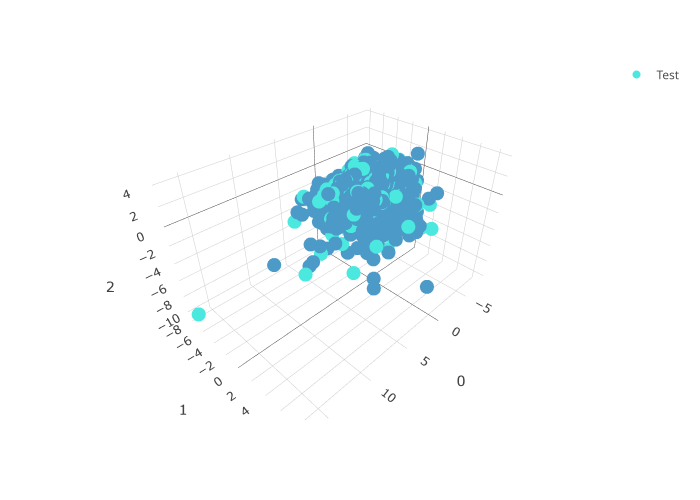

In [45]:
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

# setting Jedha color palette as default
pio.templates["jedha"] = go.layout.Template(
    layout_colorway=[
        "#4B9AC7",
        "#4BE8E0",
        "#9DD4F3",
        "#97FBF6",
        "#2A7FAF",
        "#23B1AB",
        "#0E3449",
        "#015955",
    ]
)
pio.templates.default = "jedha"
pio.renderers.default = "svg" 

fig = px.scatter_3d(PC_train, x=0, y=1, z=2)
fig.add_trace(go.Scatter3d(x=PC_test[:,0], y=PC_test[:,1], z=PC_test[:, 2], mode='markers', name="Test"))
fig.show()

In [49]:
df_plot = pd.DataFrame(PC_train)
df_plot.columns = ["PC1", "PC2", "PC3"]
df_plot["SalePrice"] = list(Y_train)
df_plot

,PC1,PC2,PC3,SalePrice
0,4.328848,-0.581093,0.611748,314813
1,-3.230328,-0.387239,1.062192,109500
2,-2.374479,-1.772095,-0.325665,163500
3,3.683356,-2.856152,-0.458296,271000
4,2.951255,-1.151338,1.292822,205000
...,...,...,...,...
1163,4.067719,-0.132826,-0.203044,337000
1164,-1.703834,-1.313257,0.754986,128000
1165,-0.338437,2.871646,0.006825,112000
1166,1.337783,-0.216404,1.974666,234000


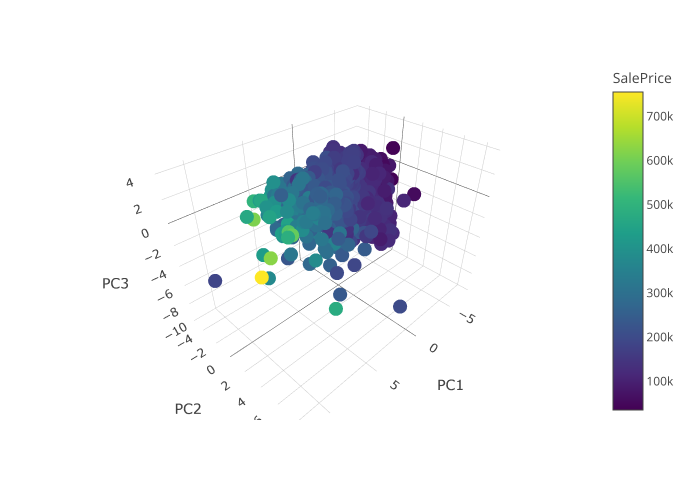

In [50]:
fig = px.scatter_3d(df_plot, x='PC1', y='PC2', z='PC3', color='SalePrice')
fig.show()